CNN 모델을 만들고, 학습하고, 검증 이미지 하나를 예측하고, 최종 테스트까지 평가하는 전체 실습 흐름

순서
→ 라이브러리 준비
→ 모델 시각화 도구 준비
→ Fashion MNIST 데이터 불러오기
→ CNN 입력 형태로 변환
→ 훈련/검증 데이터 분리
→ CNN 모델 만들기
→ 모델 구조 확인
→ 모델 컴파일
→ 콜백 설정
→ 모델 학습
→ loss 그래프 확인
→ 검증 데이터 평가
→ 이미지 하나 예측
→ 예측 확률 시각화
→ 테스트 데이터 최종 평가

1. 라이브러리 설치 및 불러오기

In [1]:
!pip install pydot graphviz
import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Fashion MNIST 데이터 불러오기

이 데이터는 다음 구조입니다.

28×28 흑백 의류 이미지
10개 클래스

반환값은 크게 두 묶음입니다.

(훈련 데이터, 테스트 데이터)

조금 더 자세히는 이렇게 생겼습니다.

(
  (train_input, train_target),
  (test_input, test_target)
)

그래서 왼쪽도 똑같이 받습니다.

변수	            의미
train_input	    훈련용 이미지
train_target	훈련용 정답
test_input	    테스트용 이미지
test_target	    테스트용 정답

구술로 말하면:

“모델이 공부할 문제와 정답, 그리고 나중에 최종 시험 볼 문제와 정답을 가져온다.”

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

3. CNN 입력 형태로 변환 + 스케일링
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

이 줄은 두 가지 일을 합니다.

첫 번째는 reshape입니다.
train_input.reshape(-1, 28, 28, 1)

원래 Fashion MNIST의 train_input shape는 보통 이렇습니다.
(60000, 28, 28)

즉:
이미지 60000장
각 이미지 28×28

그런데 CNN의 Conv2D는 입력을 4차원으로 받습니다.
(batch_size, height, width, channels)

그래서 흑백 채널 1을 추가해서 이렇게 바꿉니다.

(60000, 28, 28)
↓
(60000, 28, 28, 1)

여기서 -1은 이미지 개수를 자동으로 맞추라는 뜻입니다.

-1 = 앞쪽 개수는 알아서 계산해라
28 = 높이
28 = 너비
1 = 흑백 채널

두 번째는 스케일링입니다.
/ 255.0

이미지 픽셀값은 원래 0부터 255 사이입니다.
0 = 검정
255 = 흰색

이를 255로 나누면 0부터 1 사이가 됩니다.
0~255
↓
0~1

딥러닝 모델은 보통 입력값이 작고 일정한 범위에 있을 때 더 안정적으로 학습합니다.

In [ ]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

4. 훈련 데이터와 검증 데이터 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

이 코드는 훈련 데이터를 다시 두 개로 나눕니다.

훈련 데이터 80%
검증 데이터 20%

각 부분을 보면:

train_test_split(train_scaled, train_target, ...)

train_scaled 이미지와 train_target 정답을 함께 섞고 나눕니다.

중요한 점은 이미지와 정답의 짝이 깨지면 안 된다는 것입니다.

test_size=0.2

전체 훈련 데이터 중 20%를 검증 데이터로 사용하겠다는 뜻입니다.

Fashion MNIST 훈련 데이터는 60000장이므로:

훈련용: 48000장
검증용: 12000장

정도로 나뉩니다.

random_state=42

랜덤하게 나누되, 매번 같은 방식으로 나누게 고정하는 값입니다.

이걸 넣으면 다시 실행해도 같은 결과가 나옵니다.

왼쪽 변수들은 다음 의미입니다.

변수	                의미
train_scaled	실제 학습에 사용할 이미지
val_scaled	    학습 중 검증에 사용할 이미지
train_target	실제 학습용 정답
val_target	    검증용 정답

구술로 말하면:

“전체 훈련 데이터 중 일부를 따로 떼어내서, 모델이 공부 중에 진짜 잘하고 있는지 확인하는 모의고사 데이터로 사용한다.”

In [25]:
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

5. 데이터 shape 확인

train_input.shape
원본 훈련 이미지의 shape를 확인합니다.

보통 이렇게 나옵니다.
(60000, 28, 28)

아직 채널 차원이 없는 원본 형태입니다.
train_scaled.shape

훈련 데이터가 CNN 입력 형태로 잘 바뀌었는지 확인합니다.

train_test_split 이후라면 보통 이렇게 나옵니다.
(48000, 28, 28, 1)

뜻은:

48000장
28×28
흑백 채널 1입니다.

val_scaled.shape

검증 데이터의 shape를 확인합니다.
보통 이렇게 나옵니다.

(12000, 28, 28, 1)

뜻은:

12000장
28×28
흑백 채널 1입니다.

In [4]:
train_input.shape

(60000, 28, 28)

In [5]:
train_scaled.shape

(48000, 28, 28, 1)

In [6]:
val_scaled.shape

(12000, 28, 28, 1)

6. Sequential 모델 생성
model = keras.Sequential()

순서대로 층을 쌓는 모델을 만듭니다.

이 모델에서는 데이터가 위에서 아래로 차례대로 흐릅니다.

Input
↓
Conv2D
↓
MaxPooling2D
↓
Conv2D
↓
MaxPooling2D
↓
Flatten
↓
Dense
↓
Dropout
↓
Dense

구술로 말하면:

“이미지가 각 층을 순서대로 지나가면서 점점 분류하기 좋은 형태로 바뀌는 구조를 만든다.”

7. 입력층
model.add(keras.layers.Input(shape=(28, 28, 1)))

모델의 입력 모양을 지정합니다.
여기서 shape는 이미지 한 장의 모양입니다.

높이 28
너비 28
채널 1

그래서:
(28, 28, 1)
입니다.

주의할 점은 전체 데이터 개수인 48000이나 60000은 넣지 않습니다.

전체 데이터 shape: (48000, 28, 28, 1)
모델 입력 shape:        (28, 28, 1)

구술로 말하면:

“이 모델은 28×28짜리 흑백 이미지 한 장을 입력으로 받겠다고 선언한다.”

8. 첫 번째 Conv2D
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

첫 번째 합성곱 층입니다.

각 요소를 보면:

Conv2D(32, ...)

필터를 32개 사용하겠다는 뜻입니다.

필터 하나는 하나의 특징을 찾는 탐지기입니다.

필터 1: 선 같은 특징
필터 2: 모서리 같은 특징
필터 3: 곡선 같은 특징
...
필터 32: 또 다른 작은 패턴

kernel_size=3

3×3 필터를 사용하겠다는 뜻입니다.

즉, 이미지의 3×3 작은 영역을 보면서 특징을 찾습니다.

activation='relu'

합성곱 결과에 ReLU 함수를 적용합니다.

ReLU는 음수는 0으로 바꾸고, 양수는 그대로 둡니다.

-3 → 0
5 → 5

약한 신호나 불필요한 신호를 끄는 역할을 합니다.

padding='same'

출력의 가로세로 크기를 입력과 같게 유지합니다.

입력이:

(28, 28, 1)

이면 출력은:

(28, 28, 32)

가 됩니다.

왜냐하면:

28×28 크기는 padding='same'으로 유지
채널 수는 필터 32개 때문에 32가 됨

입니다.

파라미터 수는 다음과 같습니다.

(3×3×1 + 1) × 32 = 320

여기서 +1은 필터마다 있는 bias입니다.

9. 첫 번째 MaxPooling2D
model.add(keras.layers.MaxPooling2D(2))

2×2 영역에서 가장 큰 값만 남기는 층입니다.

입력이:

(28, 28, 32)

라면 출력은:

(14, 14, 32)

가 됩니다.

가로세로 크기는 절반으로 줄어듭니다.

28 → 14
28 → 14

하지만 채널 수는 그대로입니다.

32 → 32

MaxPooling은 학습하는 가중치가 없습니다.
그냥 최댓값을 고르는 규칙입니다.

그래서 파라미터 수는 0입니다.

구술로 말하면:

“첫 번째 합성곱에서 뽑은 32장의 특징 지도를 절반 크기로 압축해서 중요한 특징만 남긴다.”

10. 두 번째 Conv2D
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))

두 번째 합성곱 층입니다.

이번에는 필터가 64개입니다.

중요한 점은, 이 층은 원본 이미지를 직접 보는 것이 아닙니다.

첫 번째 Conv와 Pool을 거친 결과를 봅니다.

입력: (14, 14, 32)

여기서 3×3 필터 64개를 적용합니다.

padding='same'이므로 가로세로는 그대로 유지됩니다.

14×14 유지

필터가 64개이므로 출력은:

(14, 14, 64)

가 됩니다.

파라미터 수는 다음과 같습니다.

(3×3×32 + 1) × 64 = 18,496

왜 입력 채널이 32냐면, 앞 층의 출력 채널이 32였기 때문입니다.

구술로 말하면:

“두 번째 합성곱 층은 앞에서 뽑힌 32장의 특징 지도를 다시 보고, 더 복잡한 특징 64가지를 만든다.”
Maxpooling은 크기만 반으로 줄일 뿐 갯수에는 영향이 없다.

11. 두 번째 MaxPooling2D
model.add(keras.layers.MaxPooling2D(2))

다시 2×2 영역에서 가장 큰 값만 남깁니다.

입력이:

(14, 14, 64)

라면 출력은:

(7, 7, 64)

가 됩니다.

가로세로는 절반으로 줄어듭니다.

14 → 7
14 → 7

채널 수는 그대로 유지됩니다.

64 → 64

구술로 말하면:

“두 번째 Pooling은 더 복잡한 특징 64장을 다시 압축해서, 크기는 작지만 정보는 더 요약된 형태로 만든다.”

파라미터란 무엇인가?
딥러닝에서 파라미터(parameter)는 한마디로 말하면:

모델이 학습하면서 스스로 바꾸는 숫자들입니다.

즉, 사람이 직접 정하는 값이 아니라, 모델이 데이터를 보면서 “이 숫자는 이렇게 바꾸면 더 잘 맞히겠네?” 하고 계속 조정하는 값입니다.

1. 파라미터를 왜 배우냐?

모델은 처음에는 아무것도 모릅니다.

예를 들어 Fashion MNIST 이미지가 들어왔습니다.

이미지: 신발
정답: 스니커즈

처음 모델은 랜덤하게 예측합니다.

모델 예측: 셔츠
정답: 스니커즈

틀렸습니다.

그러면 모델은 손실 함수로 “얼마나 틀렸는지” 계산합니다.
그다음 optimizer, 예를 들어 Adam이 파라미터를 조금씩 고칩니다.

틀림
↓
loss 계산
↓
파라미터 수정
↓
다시 예측
↓
조금 더 잘 맞힘

이 과정을 반복하면서 모델이 점점 똑똑해집니다.

2. 파라미터의 대표: weight와 bias

딥러닝 파라미터는 보통 두 종류입니다.

구분	뜻	비유
weight, 가중치	입력값을 얼마나 중요하게 볼지 정하는 숫자	“이 특징은 중요하다/덜 중요하다”
bias, 편향	기본적으로 더해지는 보정값	“판단 기준선을 조금 옮기는 값”

뉴런 하나는 대략 이렇게 계산합니다.

출력 = 입력값 × 가중치 + bias

입력이 여러 개라면 이렇게 됩니다.

출력 = x1×w1 + x2×w2 + x3×w3 + ... + bias

여기서 w1, w2, w3와 bias가 파라미터입니다.

3. Dense 층에서 파라미터 계산

예를 들어 이런 층이 있습니다.

model.add(keras.layers.Dense(100, activation='relu'))

이 Dense 층이 입력 3136개를 받는다고 합시다.

입력 개수: 3136
뉴런 개수: 100

Dense 층은 입력 3136개가 뉴런 100개와 전부 연결됩니다.

그래서 weight 수는:

3136 × 100 = 313,600

그리고 뉴런 100개마다 bias가 1개씩 있습니다.

bias = 100개

따라서 전체 파라미터 수는:

3136 × 100 + 100 = 313,700

그래서 model.summary()에서 이렇게 나옵니다.

dense    (None, 100)    313700
4. Conv2D에서 파라미터 계산

이번에는 CNN입니다.

model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

입력이 Fashion MNIST라면 한 장의 이미지 shape는:

(28, 28, 1)

여기서 채널은 1개입니다. 흑백이니까요.

Conv2D의 필터 하나는:

3 × 3 × 1

크기의 weight를 가집니다.

즉, 필터 하나의 weight 수는:

3 × 3 × 1 = 9

필터 하나마다 bias 1개가 있습니다.

9 + 1 = 10

필터가 32개입니다.

10 × 32 = 320

그래서 첫 번째 Conv2D의 파라미터 수는:

320개

입니다.

5. 두 번째 Conv2D는 왜 파라미터가 많아지나?

두 번째 Conv2D는 보통 이렇게 되어 있습니다.

model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))

이 층의 입력은 원본 이미지가 아닙니다.
첫 번째 Conv와 Pool을 지난 결과입니다.

입력 shape: (14, 14, 32)

즉, 입력 채널이 32개입니다.

그러면 필터 하나의 크기는:

3 × 3 × 32

입니다.

weight 수는:

3 × 3 × 32 = 288

bias 1개 추가:

288 + 1 = 289

필터가 64개:

289 × 64 = 18,496

그래서 두 번째 Conv2D 파라미터 수는:

18,496개

입니다.

6. 파라미터가 있다는 말은 “학습할 숫자가 있다”는 뜻

중요합니다.

Conv2D, Dense는 파라미터가 있습니다.

왜냐하면 학습해야 할 weight와 bias가 있기 때문입니다.

반면 MaxPooling2D, Flatten, Dropout은 보통 학습 파라미터가 없습니다.

층	            파라미터 있음?	            이유
Conv2D	            있음	        필터 weight와 bias를 학습함
Dense	            있음	        연결 weight와 bias를 학습함
MaxPooling2D	    없음	        2×2에서 최댓값만 고르는 규칙
Flatten	            없음	        모양만 한 줄로 바꿈
Dropout	            없음	        학습 중 일부 뉴런을 랜덤하게 끔

7. 그러면 파라미터가 많을수록 좋은가?

무조건 아닙니다.

파라미터가 많으면 모델이 더 복잡한 패턴을 배울 수 있습니다.
하지만 동시에 위험도 커집니다.

파라미터 많음
→ 표현력 증가
→ 더 복잡한 문제 가능
→ 하지만 과적합 위험 증가
→ 학습 시간 증가
→ 메모리 사용 증가

예를 들어 Dense 층 하나가:

313,700개

의 파라미터를 가질 수 있습니다.

반면 첫 번째 Conv2D는:

320개

밖에 안 됩니다.

그런데도 CNN이 이미지에서 강한 이유는 필터를 공유해서 쓰기 때문입니다.

8. 파라미터를 사람 공부에 비유하면

모델을 학생이라고 보면, 파라미터는 학생 머릿속의 판단 기준입니다.

처음에는 기준이 엉망입니다.

신발을 셔츠라고 생각함
가방을 코트라고 생각함

학습을 하면서 기준이 바뀝니다.

밑창 모양이 있으면 신발일 가능성이 높다
손잡이 모양이 있으면 가방일 가능성이 높다
소매 형태가 있으면 셔츠일 가능성이 높다

이 판단 기준이 숫자로 저장된 것이 파라미터입니다.

9. 핵심 정리
질문	                        답
파라미터가 뭐야?	     모델이 학습하면서 조정하는 숫자
대표 파라미터는?	     weight와 bias
누가 바꾸나?	        optimizer가 loss를 보고 바꿈
왜 필요해?	            데이터를 보고 더 잘 예측하기 위해
Conv2D 파라미터는?	    필터의 weight와 bias
Dense 파라미터는?	    입력과 뉴런 사이의 weight와 bias
많으면 좋은가?	         꼭 그렇지 않음. 과적합 위험도 커짐
한 문장으로 결론

파라미터는 모델이 정답을 더 잘 맞히기 위해 학습 과정에서 계속 수정하는 내부 숫자이며, CNN에서는 필터 값과 bias, Dense에서는 연결 가중치와 bias가 파라미터입니다.

In [7]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [8]:
model.add(keras.layers.MaxPooling2D(2))

In [9]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

12. Flatten
model.add(keras.layers.Flatten())

CNN을 지난 데이터의 모양은 다음과 같습니다.
(7, 7, 64)

이걸 Dense 층에 넣기 위해 한 줄로 펼칩니다.
7 × 7 × 64 = 3136

즉:
(7, 7, 64)
↓
3136개 숫자

batch까지 포함하면:

(None, 7, 7, 64)
↓
(None, 3136)

구술로 말하면:

“CNN이 뽑아낸 특징 지도들을 최종 분류기에 넣기 위해 한 줄짜리 벡터로 정리한다.”

15. Dense 은닉층
model.add(keras.layers.Dense(100, activation='relu'))

3136개의 특징을 받아서 100개의 뉴런으로 처리합니다.
파라미터 수는 다음과 같습니다.
3136 × 100 + 100 = 313,700

여기서 +100은 각 뉴런의 bias입니다.
이 층은 CNN이 뽑아낸 특징들을 조합해서 최종 판단에 가까운 정보를 만듭니다.

구술로 말하면:
“3136개의 특징을 100개의 판단 기준으로 압축하고 조합한다.”

16. Dropout
model.add(keras.layers.Dropout(0.4))

과적합을 줄이기 위한 층입니다.
0.4는 학습할 때 뉴런의 40%를 랜덤하게 꺼버린다는 뜻입니다.

100개 뉴런 중 약 40개를 학습 때마다 랜덤하게 끔
왜 이렇게 하냐면 모델이 특정 뉴런 몇 개에만 지나치게 의존하지 못하게 하기 위해서입니다.

주의할 점은 Dropout은 학습 중에만 작동합니다.
평가나 예측할 때는 모든 뉴런을 사용합니다.

17. 출력층
model.add(keras.layers.Dense(10, activation='softmax'))

최종 출력층입니다.

Fashion MNIST는 10개 클래스 분류 문제입니다.

0 티셔츠
1 바지
2 스웨터
3 드레스
4 코트
5 샌달
6 셔츠
7 스니커즈
8 가방
9 앵클 부츠

그래서 뉴런이 10개입니다.

softmax는 10개의 출력값을 확률처럼 바꿔줍니다.

예를 들어:

[0.01, 0.02, 0.03, 0.80, ...]

처럼 각 클래스일 가능성을 보여줍니다.

파라미터 수는 다음과 같습니다.

100 × 10 + 10 = 1,010

In [10]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

18. 모델 구조 확인
model.summary()

모델의 층별 구조를 표로 보여줍니다.

여기서 확인할 것은 세 가지입니다.

1. 각 층의 출력 shape
2. 각 층의 파라미터 수
3. 전체 파라미터 수

정상 구조는 대략 이렇습니다.

Conv2D             (None, 28, 28, 32)      320
MaxPooling2D       (None, 14, 14, 32)      0
Conv2D             (None, 14, 14, 64)      18,496
MaxPooling2D       (None, 7, 7, 64)        0
Flatten            (None, 3136)            0
Dense              (None, 100)             313,700
Dropout            (None, 100)             0
Dense              (None, 10)              1,010

여기서 None은 batch size입니다.

한 번에 몇 장을 넣을지는 아직 고정하지 않았다는 뜻

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
plot_model(
    model,
    to_file='cnn_model.png',
    show_shapes=True,
    show_layer_names=True
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
keras.utils.plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


19. 모델 그림 출력
keras.utils.plot_model(model)

모델 구조를 그림으로 출력합니다.

단, 이 코드는 Graphviz가 제대로 설치되어 있어야 작동합니다.

keras.utils.plot_model(model, show_shapes=True)

모델 구조를 그림으로 보여주되, 각 층의 shape도 같이 표시합니다.

show_shapes=True가 있으므로 다음 같은 정보가 그림에 나옵니다.

(None, 28, 28, 1)
(None, 28, 28, 32)
(None, 14, 14, 32)
...

수업에서는 이 옵션이 더 좋습니다.
왜냐하면 CNN에서는 shape 흐름을 읽는 것이 핵심이기 때문입니다.

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

20. 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

모델을 학습할 준비를 시키는 단계입니다.
모델 구조만 만들면 아직 학습할 수 없습니다.
컴파일 단계에서 세 가지를 정합니다.

optimizer='adam'

모델이 틀렸을 때 가중치를 어떻게 수정할지 정합니다.
Adam은 초급 실습에서 가장 많이 쓰는 optimizer입니다.

구술로 말하면:
“틀린 정도를 보고 가중치를 어느 방향으로 얼마나 고칠지 정하는 방식이다.”

loss='sparse_categorical_crossentropy'

손실 함수입니다.
모델이 얼마나 틀렸는지 계산합니다.
Fashion MNIST는 다음 조건입니다.

여러 클래스 중 하나를 맞히는 분류 문제
정답이 0~9 정수 라벨
그래서 sparse_categorical_crossentropy를 씁니다.

metrics=['accuracy']
학습 중에 정확도를 같이 보여달라는 뜻입니다.
accuracy는 Keras가 알고 있는 지표 이름입니다.

정리하면:

loss = 모델이 학습할 때 참고하는 오답 점수
accuracy = 사람이 보기 쉽게 확인하는 정답률입니다.

21. ModelCheckpoint 콜백
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)

학습 중 가장 좋은 모델을 저장하는 콜백입니다.
'best-cnn-model.keras'
저장할 파일 이름입니다.

save_best_only=True
검증 성능이 가장 좋았던 모델만 저장하겠다는 뜻입니다.
즉, 마지막 epoch의 모델이 아니라, 가장 성능이 좋았던 순간의 모델을 저장합니다.

구술로 말하면:
“공부하는 중에 모의고사 점수가 제일 좋았던 상태를 저장해 둔다.”

22. EarlyStopping 콜백
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
학습을 너무 오래 하지 않도록 중간에 멈추는 콜백입니다.

patience=2
검증 성능이 2번 연속 좋아지지 않으면 학습을 멈춥니다.

restore_best_weights=True
학습이 끝난 뒤, 가장 좋았던 시점의 가중치로 되돌립니다.

이게 중요합니다.
EarlyStopping이 발동된 마지막 시점은 성능이 가장 좋은 시점이 아닐 수 있습니다.
그래서 가장 좋았던 가중치로 복원하는 겁니다.

구술로 말하면:
“더 공부해도 모의고사 성적이 좋아지지 않으면 멈추고, 가장 점수가 좋았던 시점으로 되돌린다.”

23. 모델 학습
history = model.fit(train_scaled, train_target, epochs=20, 
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])
모델을 실제로 학습시키는 코드입니다.

model.fit(...)
모델을 훈련시키는 함수입니다.

train_scaled
학습용 이미지입니다.

train_target
학습용 정답입니다.

epochs=20
전체 훈련 데이터를 최대 20번 반복해서 학습하겠다는 뜻입니다.
하지만 EarlyStopping이 있기 때문에 20번 전에 멈출 수 있습니다.

validation_data=(val_scaled, val_target)
학습 중간에 검증할 데이터를 지정합니다.
모델은 train_scaled로 공부하고, val_scaled로 중간 실력을 확인합니다.

callbacks=[checkpoint_cb, early_stopping_cb]
학습 중 사용할 콜백들을 지정합니다.

여기서는 두 가지입니다.

ModelCheckpoint: 가장 좋은 모델 저장
EarlyStopping: 성능 개선이 없으면 조기 종료
history = ...

학습 과정의 기록을 history 변수에 저장합니다.

여기에는 다음 같은 값들이 들어 있습니다.

loss
accuracy
val_loss
val_accuracy





In [15]:
# 모델 컴파일과 훈련
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, 
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8077 - loss: 0.5341 - val_accuracy: 0.8771 - val_loss: 0.3272
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8738 - loss: 0.3514 - val_accuracy: 0.8955 - val_loss: 0.2847
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8929 - loss: 0.2998 - val_accuracy: 0.9068 - val_loss: 0.2583
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9015 - loss: 0.2696 - val_accuracy: 0.9111 - val_loss: 0.2405
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9107 - loss: 0.2452 - val_accuracy: 0.9135 - val_loss: 0.2350
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9179 - loss: 0.2222 - val_accuracy: 0.9158 - val_loss: 0.2290
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9251 - loss: 0.2066 - val_accuracy: 0.9158 - val_loss: 0.2393
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9280 - loss: 0.1951 - 

24. 훈련 loss와 검증 loss 그래프
plt.plot(history.history['loss'], label='train')
훈련 손실값을 그래프로 그립니다.
history.history['loss']에는 epoch마다 기록된 훈련 loss가 들어 있습니다.

plt.plot(history.history['val_loss'], label='val')
검증 손실값을 그래프로 그립니다.

history.history['val_loss']에는 epoch마다 기록된 검증 loss가 들어 있습니다.
plt.xlabel('epoch')
x축 이름을 epoch로 표시합니다.

plt.ylabel('loss')
y축 이름을 loss로 표시합니다.


plt.legend()
그래야 그래프에 train, val 범례가 표시됩니다.

plt.show()
그래프를 화면에 보여줍니다.

이 그래프에서 봐야 할 것
상황	                                 해석
train loss 감소, val loss 감소	       정상 학습
train loss 감소, val loss 증가	       과적합 가능성
둘 다 감소하지 않음	                    학습 부족 또는 구조 문제
val loss가 어느 순간 멈춤	            EarlyStopping 대상

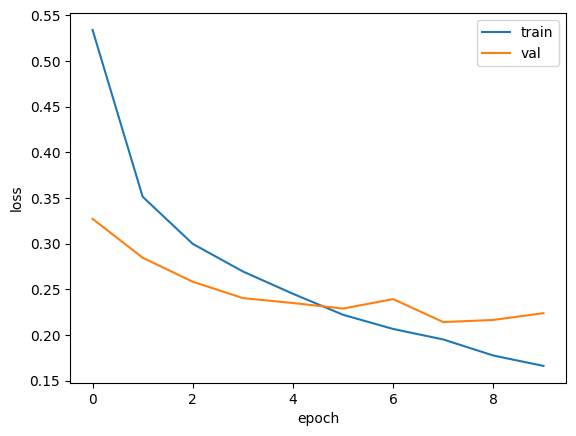

In [26]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

25. 검증 데이터 평가
model.evaluate(val_scaled, val_target)
검증 데이터로 모델 성능을 평가합니다.

출력은 보통 이렇게 나옵니다.
loss, accuracy

예를 들어:

[0.25, 0.91]

이라면:

검증 손실: 0.25
검증 정확도: 91%입니다.

In [17]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2142


[0.2141769975423813, 0.9241666793823242]

26. 검증 이미지 하나 보기
plt.imshow(val_scaled[0].reshape(28,28), cmap='gray_r')
검증 데이터의 첫 번째 이미지를 화면에 보여줍니다.

val_scaled[0]
검증 데이터 중 첫 번째 이미지입니다.

shape는 다음과 같습니다.
(28, 28, 1)

.reshape(28,28)
이미지를 화면에 그리기 위해 채널 차원 1을 잠깐 제거합니다.
(28, 28, 1)
↓
(28, 28)
cmap='gray_r'

흑백 반전 컬러맵으로 보여줍니다.\
gray_r에서 r은 reverse, 즉 반전을 뜻합니다.

plt.show()
이미지를 화면에 출력합니다.

구술로 말하면:
“검증 데이터 첫 번째 이미지를 눈으로 확인해 본다.”

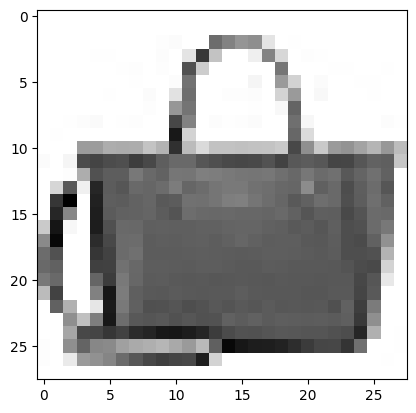

In [18]:
plt.imshow(val_scaled[0].reshape(28,28), cmap='gray_r')
plt.show()

In [19]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[9.4584961e-16 1.3930858e-28 2.6566552e-19 2.7238285e-20 5.1906215e-17
  2.3189670e-15 1.7500123e-17 1.3005993e-15 1.0000000e+00 1.3299478e-14]]


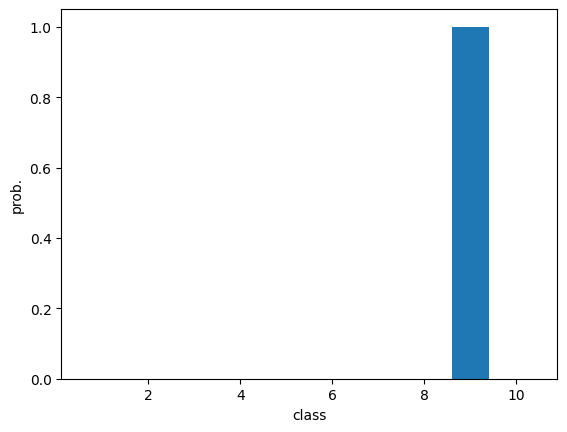

In [20]:
plt.bar(range(1,11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [21]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [22]:
import numpy as np
print(classes[np.argmax(preds)])

가방


27. 테스트 데이터 스케일링
test_scaled = test_input.reshape(-1, 28,28, 1) /255.0

테스트 데이터도 CNN 입력 형태로 바꿉니다.

원래 test_input은 보통:

(10000, 28, 28)

입니다.

이를:

(10000, 28, 28, 1)

로 바꿉니다.

그리고 255로 나누어서 0~1 범위로 스케일링합니다.

띄어쓰기만 조금 다듬으면 이렇게 쓰는 게 좋습니다.

test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

28. 테스트 데이터 최종 평가

model.evaluate(test_scaled, test_target)
최종 테스트 데이터로 모델을 평가합니다.

검증 데이터는 학습 중에 참고한 데이터입니다.
하지만 테스트 데이터는 최종 시험용입니다.

구술로 말하면:
“학습과 검증이 끝난 모델을, 마지막으로 한 번도 학습에 사용하지 않은 테스트 데이터로 평가한다.”

출력은 보통:
test_loss, test_accuracy 입니다.

In [23]:
test_scaled = test_input.reshape(-1, 28,28, 1) /255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9165 - loss: 0.2373


[0.23730966448783875, 0.9164999723434448]

전체 흐름을 구술로 설명하면

이 코드는 먼저 CNN 모델 학습에 필요한 패키지를 설치하고, Keras, scikit-learn, matplotlib, plot_model을 불러옵니다. 그다음 Fashion MNIST 데이터를 가져옵니다. 이 데이터는 28×28 크기의 흑백 의류 이미지와 0부터 9까지의 정답 라벨로 구성되어 있습니다.

처음 불러온 이미지는 (60000, 28, 28) 형태입니다. 하지만 Conv2D는 (batch_size, height, width, channels) 형태의 4차원 입력을 요구하기 때문에, reshape(-1, 28, 28, 1)을 사용해서 데이터를 (60000, 28, 28, 1)로 바꿉니다. 여기서 마지막 1은 흑백 채널을 뜻합니다. 동시에 255로 나누어 픽셀값을 0부터 1 사이로 스케일링합니다.

그다음 train_test_split으로 훈련 데이터 중 20%를 검증 데이터로 분리합니다. 모델은 80% 데이터로 학습하고, 20% 데이터로 중간 성능을 확인합니다.

이후 Sequential 모델을 만들고, 입력층에서 (28, 28, 1) 이미지를 받도록 설정합니다. 첫 번째 Conv2D는 3×3 필터 32개로 이미지에서 기본 특징을 뽑습니다. padding='same'을 사용했으므로 크기는 28×28로 유지되고, 필터가 32개라서 출력은 (28, 28, 32)가 됩니다. 그다음 MaxPooling2D가 가로세로 크기를 절반으로 줄여 (14, 14, 32)로 만듭니다.

두 번째 Conv2D는 앞에서 뽑힌 32장의 특징 지도를 보고, 64개의 더 복잡한 특징 지도를 만듭니다. 출력은 (14, 14, 64)가 됩니다. 다시 MaxPooling을 적용해서 (7, 7, 64)로 줄입니다. 여기까지가 이미지 특징 추출 단계입니다.

그다음 Flatten은 (7, 7, 64)를 한 줄로 펼쳐서 3136개의 숫자로 만듭니다. Dense(100)은 이 3136개 특징을 100개의 판단 기준으로 조합합니다. Dropout(0.4)은 학습 중 뉴런의 40%를 랜덤하게 꺼서 과적합을 줄입니다. 마지막 Dense(10, softmax)는 10개 의류 클래스 각각의 확률을 출력합니다.

모델 구조를 summary()로 확인하고, 필요하면 plot_model()로 그림을 그립니다. 그다음 compile()에서 Adam optimizer, sparse categorical crossentropy 손실 함수, accuracy 지표를 지정합니다. ModelCheckpoint는 가장 성능이 좋았던 모델을 저장하고, EarlyStopping은 검증 성능이 더 이상 좋아지지 않으면 학습을 조기에 멈춥니다.

학습이 끝나면 history에 저장된 훈련 loss와 검증 loss를 그래프로 그립니다. 이후 검증 데이터로 모델 성능을 평가하고, 검증 이미지 하나를 직접 화면에 출력합니다. 그 이미지 하나를 model.predict()로 예측한 뒤, 10개 클래스에 대한 확률을 출력하고 막대그래프로 확인합니다. 마지막으로 가장 높은 확률의 인덱스를 np.argmax()로 찾아서 실제 클래스 이름으로 출력합니다.

마지막에는 테스트 데이터도 같은 방식으로 4차원 변환과 스케일링을 한 뒤, model.evaluate(test_scaled, test_target)으로 최종 성능을 평가합니다.

핵심 요약
단계	코드 핵심	의미
데이터 로드	fashion_mnist.load_data()	이미지와 정답 가져오기
4D 변환	reshape(-1,28,28,1)	CNN 입력 형태로 변경
검증 분리	train_test_split()	모의고사용 데이터 만들기
특징 추출	Conv2D, MaxPooling2D	이미지 특징 뽑고 압축
분류 준비	Flatten, Dense	특징을 한 줄로 정리하고 판단
과적합 완화	Dropout(0.4)	일부 뉴런 랜덤 제거
컴파일	compile()	학습 방식 설정
학습	fit()	모델 훈련
시각화	plt.plot()	loss 변화 확인
예측	predict()	이미지 하나 분류
최종 평가	evaluate()	테스트 성능 확인

한 문장으로 정리하면:

이 코드는 Fashion MNIST 이미지를 CNN 입력 형태로 바꾸고, Conv2D와 MaxPooling으로 특징을 추출한 뒤, Dense 층으로 10개 의류 클래스를 분류하고, 학습 과정과 예측 결과까지 확인하는 전체 CNN 실습 코드입니다.

기타 질문 정리

Dense가 뭐니?

Dense는 딥러닝에서 가장 기본적인 층입니다.
한국어로는 보통 완전연결층, 영어로는 Fully Connected Layer라고 합니다.

한마디로 말하면:

앞 층에서 넘어온 모든 숫자를 모든 뉴런에 연결해서 최종 판단을 만드는 층입니다.

1. Dense를 왜 쓰냐?

CNN 앞부분은 이미지에서 특징을 뽑습니다.

Conv2D → MaxPooling2D → Conv2D → MaxPooling2D

여기까지는 이런 일을 합니다.

선 찾기
모서리 찾기
곡선 찾기
신발 앞코 찾기
가방 손잡이 같은 특징 찾기

그런데 특징만 뽑았다고 끝이 아닙니다.

이제 모델이 판단해야 합니다.

이 특징들을 종합해보니 티셔츠인가?
바지인가?
스니커즈인가?
가방인가?

이 종합 판단을 하는 층이 Dense입니다.

2. 사용자님 CNN 코드에서 Dense 위치

사용자님 코드 흐름은 이렇습니다.

model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

여기서 Dense는 두 번 나옵니다.

model.add(keras.layers.Dense(100, activation='relu'))

그리고:

model.add(keras.layers.Dense(10, activation='softmax'))

두 Dense의 역할이 다릅니다.

코드	역할
Dense(100, activation='relu')	CNN이 뽑은 특징을 종합하는 중간 판단층
Dense(10, activation='softmax')	10개 클래스 중 무엇인지 최종 분류하는 출력층
3. Dense는 왜 “완전연결층”이냐?

예를 들어 Flatten 이후 값이 3136개라고 합시다.

Flatten 결과 = 3136개 숫자

그리고 Dense가 이렇게 되어 있습니다.

Dense(100)

이 말은 뉴런이 100개라는 뜻입니다.

Dense에서는 3136개 입력이 100개 뉴런 각각에 전부 연결됩니다.

입력 3136개
   ↓ 전부 연결
뉴런 100개

조금 더 정확히 말하면:

3136개 입력값이 1번 뉴런에도 전부 연결됨
3136개 입력값이 2번 뉴런에도 전부 연결됨
3136개 입력값이 3번 뉴런에도 전부 연결됨
...
3136개 입력값이 100번 뉴런에도 전부 연결됨

그래서 완전연결층이라고 부릅니다.

4. Dense 안에서는 무슨 계산을 하냐?

뉴런 하나는 대략 이렇게 계산합니다.

출력 = 입력1×가중치1 + 입력2×가중치2 + 입력3×가중치3 + ... + bias

조금 단순화해서 입력이 3개만 있다고 해봅시다.

입력 = [2, 4, 1]
가중치 = [0.5, -1.0, 2.0]
bias = 0.3

뉴런 하나의 계산은:

2×0.5 + 4×(-1.0) + 1×2.0 + 0.3
= 1 - 4 + 2 + 0.3
= -0.7

여기에 ReLU를 쓰면:

ReLU(-0.7) = 0

이런 식입니다.

Dense의 뉴런 100개는 각각 자기만의 가중치와 bias를 가지고 계산합니다.

5. 왜 Dense(100)의 파라미터가 313,700개야?

사용자님 모델에서는 두 번째 MaxPooling 후 shape가 이렇습니다.

(7, 7, 64)

Flatten을 하면:

7 × 7 × 64 = 3136

즉, Dense에 들어가는 입력 숫자가 3136개입니다.

Dense는 이렇게 되어 있습니다.

Dense(100)

뉴런이 100개입니다.

Dense는 모든 입력과 모든 뉴런을 연결합니다.

그래서 weight 수는:

3136 × 100 = 313,600

뉴런 100개마다 bias가 1개씩 있습니다.

bias = 100개

따라서 전체 파라미터 수는:

3136 × 100 + 100 = 313,700

그래서 model.summary()에서 이렇게 나옵니다.

dense    (None, 100)    313700
6. 그럼 Dense(10)는 뭐야?

마지막 줄입니다.

model.add(keras.layers.Dense(10, activation='softmax'))

이건 출력층입니다.

Fashion MNIST는 10개 클래스입니다.

0 티셔츠
1 바지
2 스웨터
3 드레스
4 코트
5 샌달
6 셔츠
7 스니커즈
8 가방
9 앵클 부츠

그래서 마지막 Dense의 뉴런 수가 10개입니다.

이 10개 뉴런은 각각 이렇게 해석할 수 있습니다.

1번 뉴런: 티셔츠 점수
2번 뉴런: 바지 점수
3번 뉴런: 스웨터 점수
...
10번 뉴런: 앵클 부츠 점수

그리고 softmax가 이 점수들을 확률처럼 바꿔줍니다.

티셔츠 확률: 0.01
바지 확률: 0.02
스웨터 확률: 0.03
...
스니커즈 확률: 0.88
7. CNN에서 Dense의 역할을 구술로 설명하면

CNN 앞부분은 이미지를 보고 특징을 뽑습니다.

Conv2D:
이미지에서 선, 모서리, 곡선, 부분 형태를 찾음

MaxPooling:
중요한 특징만 남기고 크기를 줄임

그 결과 마지막에는 이런 데이터가 남습니다.

(7, 7, 64)

이건 말로 풀면:

7×7 위치마다
64종류의 특징 정보가 남아 있다

그런데 최종적으로는 “이 이미지가 무엇인가?”를 판단해야 합니다.
그래서 Flatten으로 한 줄로 펼칩니다.

7×7×64 = 3136개 특징

그리고 Dense가 이 3136개 특징을 종합합니다.

이 특징들을 보니 신발 같다
이 특징들을 보니 가방은 아니다
이 특징들을 보니 스니커즈일 가능성이 높다

마지막 Dense(10)가 10개 클래스 확률을 출력합니다.

8. Dense를 비유하면

Dense는 최종 판정 회의입니다.

CNN 앞부분은 현장 조사팀입니다.

Conv2D 팀:
“여기에 선이 있습니다.”
“여기에 곡선이 있습니다.”
“여기에 신발 앞코 같은 특징이 있습니다.”
“여기에 밑창 같은 패턴이 있습니다.”

Flatten은 보고서를 한 줄로 정리합니다.

특징 보고서 3136개 항목

Dense는 그 보고서를 보고 판단합니다.

“이 정도 특징 조합이면 스니커즈일 가능성이 높다.”

출력 Dense는 최종 발표를 합니다.

스니커즈 88%
샌달 5%
가방 2%
...
9. Dense와 Conv2D의 차이
구분	Conv2D	Dense
보는 방식	작은 필터로 부분 영역을 봄	모든 입력을 한꺼번에 연결
주 역할	이미지 특징 추출	특징 종합 및 최종 판단
입력 형태	3D feature map	1D 벡터
파라미터 구조	필터 weight 공유	모든 입력-뉴런 연결
이미지 위치 정보	어느 정도 유지	Flatten 후 약해짐
10. 핵심 한 문장

Dense는 앞에서 추출된 특징들을 모두 연결해서 종합 판단을 내리는 층입니다. CNN에서는 보통 Conv2D와 Pooling이 특징을 뽑고, Flatten이 한 줄로 정리한 뒤, Dense가 최종 분류 판단을 합니다.

(28, 28, 1)
↓
(28, 28)
왜 채널 차원 1을 제거해야해?

좋은 질문입니다. 핵심은 이겁니다.

모델은 CNN 계산을 위해 (28, 28, 1)을 원하지만, plt.imshow()는 흑백 이미지를 그릴 때 보통 (28, 28) 형태를 가장 자연스럽게 받습니다.

1. 모델이 보는 이미지 형태

CNN 모델에 넣을 때는 이미지가 4차원이어야 합니다.

(batch, height, width, channels)

이미지 한 장만 보면:

(28, 28, 1)

입니다.

여기서 마지막 1은:

흑백 채널 1개

라는 뜻입니다.

즉, 모델 입장에서는 이렇게 말하는 겁니다.

높이 28, 너비 28, 흑백 채널 1개짜리 이미지

CNN은 이 채널 차원이 필요합니다.
왜냐하면 Conv2D 필터가 다음 구조로 계산되기 때문입니다.

필터 크기 = 3 × 3 × 입력 채널 수

Fashion MNIST는 흑백이라:

3 × 3 × 1

CIFAR-10 같은 컬러 이미지는 RGB라:

3 × 3 × 3

이 됩니다.

2. 그런데 화면에 그릴 때는 왜 (28, 28)이 좋나?

plt.imshow()는 2D 배열을 흑백 이미지로 해석할 수 있습니다.

plt.imshow(image_2d, cmap='gray_r')

여기서 image_2d가:

(28, 28)

이면 matplotlib은 이렇게 이해합니다.

아, 이건 28×28짜리 밝기값 이미지구나.
각 숫자를 흑백 명암으로 그리면 되겠네.

즉, 흑백 이미지를 그릴 때는 굳이 마지막 채널 차원 1이 없어도 됩니다.

오히려 초급 실습에서는 (28, 28)로 바꾸는 게 명확합니다.

3. 그럼 (28, 28, 1)로는 못 그려?

환경에 따라 될 때도 있고, 안 될 때도 있습니다.

하지만 일반적으로 imshow()에서 이미지 shape는 다음 중 하나가 가장 표준입니다.

이미지 종류	권장 shape
흑백 이미지	(height, width)
RGB 컬러 이미지	(height, width, 3)
RGBA 이미지	(height, width, 4)

즉:

(28, 28)      → 흑백 이미지로 자연스럽게 표시
(28, 28, 3)   → 컬러 RGB 이미지로 표시
(28, 28, 1)   → 애매하거나 경고/오류 가능

(28, 28, 1)은 사람 눈에는 흑백 이미지지만, matplotlib 입장에서는 “채널이 1개 있는 3차원 배열”입니다. 그래서 버전에 따라 처리 방식이 다를 수 있습니다.

그래서 안전하게:

val_scaled[0].reshape(28, 28)

또는:

val_scaled[0].squeeze()

를 씁니다.

4. reshape(28, 28)이 하는 일

원래 검증 이미지 한 장은 이렇게 생겼습니다.

val_scaled[0].shape

결과:

(28, 28, 1)

이것을:

val_scaled[0].reshape(28, 28)

하면:

(28, 28)

로 바뀝니다.

즉, 데이터 자체의 픽셀값이 바뀌는 게 아닙니다.
그냥 모양만 바꿔서 화면 출력에 맞게 만드는 것입니다.

5. 모델 예측할 때는 절대 이렇게 하면 안 됨

주의해야 합니다.

화면에 보여줄 때는:

plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')

이렇게 해도 됩니다.

하지만 모델에 예측시킬 때는 이렇게 하면 안 됩니다.

model.predict(val_scaled[0].reshape(28, 28))

왜냐하면 모델은 4차원 입력을 기대하기 때문입니다.

모델 예측에는 이렇게 넣어야 합니다.

model.predict(val_scaled[0:1])

여기서 shape는:

(1, 28, 28, 1)

입니다.

즉:

이미지 1장, 높이 28, 너비 28, 채널 1

입니다.

6. 화면 출력용 vs 모델 입력용
목적	코드	shape
화면에 이미지 보기	val_scaled[0].reshape(28, 28)	(28, 28)
모델에 이미지 1장 예측	val_scaled[0:1]	(1, 28, 28, 1)
이미지 한 장 원본	val_scaled[0]	(28, 28, 1)
7. reshape 대신 squeeze도 가능

채널 차원 1만 제거하고 싶으면 이렇게 써도 됩니다.

plt.imshow(val_scaled[0].squeeze(), cmap='gray_r')
plt.show()

squeeze()는 크기가 1인 차원을 제거합니다.

(28, 28, 1)
↓
(28, 28)

다만 초급 수업에서는 reshape(28, 28)이 눈에 더 직관적입니다.

핵심 정리

채널 차원 1은 CNN 모델이 계산할 때 필요한 정보입니다. 하지만 화면에 흑백 이미지를 그릴 때는 픽셀 밝기값만 있으면 되므로 (28, 28) 형태로 바꿔서 보여주는 것입니다.

즉:

모델 입력용: (28, 28, 1)
화면 출력용: (28, 28)

이렇게 목적이 다릅니다.

In [ ]:
# ============================================================
# 0. 패키지 설치
# ============================================================

!pip install pydot graphviz
# !pip install 패키지명
# Jupyter Notebook 셀에서 외부 Python 패키지를 설치하는 명령어입니다.
# pydot: Keras 모델 구조를 그래프 형태로 변환할 때 사용됩니다.
# graphviz: 모델 구조를 이미지로 그릴 때 사용됩니다.
# 주의: Windows에서는 pip graphviz 외에도 Graphviz 프로그램 본체 설치가 필요할 수 있습니다.


# ============================================================
# 1. 라이브러리 불러오기
# ============================================================

import keras
# keras 라이브러리를 불러옵니다.
# Keras는 딥러닝 모델을 쉽게 만들 수 있게 해주는 고수준 API입니다.
# 여기서는 Sequential 모델, Conv2D, MaxPooling2D, Dense, Dropout, callbacks 등을 사용합니다.

import numpy as np
# numpy를 np라는 짧은 이름으로 불러옵니다.
# NumPy는 배열 계산을 위한 대표적인 Python 라이브러리입니다.
# 여기서는 np.argmax()를 사용해서 예측 확률이 가장 높은 클래스 번호를 찾습니다.

import matplotlib.pyplot as plt
# matplotlib의 pyplot 모듈을 plt라는 이름으로 불러옵니다.
# 그래프, 이미지, 막대그래프 등을 그릴 때 사용합니다.
# 여기서는 loss 그래프, 이미지 출력, 예측 확률 막대그래프에 사용합니다.

from sklearn.model_selection import train_test_split
# scikit-learn에서 train_test_split 함수를 가져옵니다.
# 기본 형태:
# train_test_split(입력데이터, 정답데이터, test_size=비율, random_state=숫자)
# 전체 데이터를 훈련용 데이터와 검증용 데이터로 나눌 때 사용합니다.

from tensorflow.keras.utils import plot_model
# TensorFlow Keras의 plot_model 함수를 가져옵니다.
# 기본 형태:
# plot_model(model, to_file='파일명.png', show_shapes=True)
# Keras 모델 구조를 이미지 파일로 시각화할 때 사용합니다.


# ============================================================
# 2. Fashion MNIST 데이터 불러오기
# ============================================================

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
# keras.datasets.fashion_mnist.load_data()
# Keras에 내장된 Fashion MNIST 데이터를 불러오는 함수입니다.
#
# 반환 구조:
# (train_input, train_target), (test_input, test_target)
#
# train_input  : 훈련용 이미지 데이터입니다.
# train_target : 훈련용 정답 라벨입니다.
# test_input   : 최종 평가용 이미지 데이터입니다.
# test_target  : 최종 평가용 정답 라벨입니다.
#
# Fashion MNIST는 28x28 크기의 흑백 의류 이미지 데이터입니다.
# 클래스는 총 10개입니다.
# 예: 티셔츠, 바지, 스웨터, 드레스, 코트, 샌달, 셔츠, 스니커즈, 가방, 앵클부츠


# ============================================================
# 3. CNN 입력 형태로 변환 + 스케일링
# ============================================================

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
# train_input.reshape(-1, 28, 28, 1)
# 원래 train_input의 shape는 보통 (60000, 28, 28)입니다.
# CNN의 Conv2D는 4차원 입력을 요구합니다.
#
# Conv2D 입력 기본 형태:
# (batch_size, height, width, channels)
#
# -1 : 이미지 개수는 자동으로 계산하라는 뜻입니다.
# 28 : 이미지 높이입니다.
# 28 : 이미지 너비입니다.
# 1  : 흑백 이미지의 채널 수입니다.
#
# 따라서 shape가 다음처럼 바뀝니다.
# (60000, 28, 28) → (60000, 28, 28, 1)
#
# / 255.0
# 이미지 픽셀값은 원래 0~255 범위입니다.
# 255.0으로 나누면 0~1 범위로 바뀝니다.
# 딥러닝 모델은 입력값이 작고 일정한 범위에 있을 때 더 안정적으로 학습합니다.

test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
# test_input도 train_input과 같은 방식으로 처리합니다.
# 원래 shape: (10000, 28, 28)
# 변환 후 shape: (10000, 28, 28, 1)
# 테스트 데이터도 훈련 데이터와 같은 기준으로 스케일링해야 합니다.
# 훈련 데이터는 0~1인데 테스트 데이터가 0~255이면 평가가 왜곡됩니다.


# ============================================================
# 4. 훈련 데이터 / 검증 데이터 분리
# ============================================================

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled,
    # 나눌 입력 데이터입니다.
    # 여기서는 CNN 입력 형태로 변환되고 스케일링된 훈련 이미지입니다.

    train_target,
    # 나눌 정답 데이터입니다.
    # train_scaled와 train_target은 서로 짝이 맞아야 합니다.
    # 예: train_scaled[0]의 정답은 train_target[0]입니다.

    test_size=0.2,
    # 전체 훈련 데이터 중 20%를 검증 데이터로 분리합니다.
    # Fashion MNIST 훈련 데이터 60000장 기준:
    # 훈련용 약 48000장, 검증용 약 12000장으로 나뉩니다.

    random_state=42
    # 데이터를 랜덤하게 나누되, 매번 같은 방식으로 나누기 위한 고정값입니다.
    # 이 값을 지정하면 코드를 다시 실행해도 같은 훈련/검증 분리가 유지됩니다.
)
# train_test_split의 반환 순서는 입력 데이터 train/validation, 정답 데이터 train/validation입니다.
#
# 반환 결과:
# train_scaled : 실제 학습에 사용할 이미지 데이터
# val_scaled   : 학습 중 검증에 사용할 이미지 데이터
# train_target : 실제 학습에 사용할 정답 데이터
# val_target   : 검증에 사용할 정답 데이터


# ============================================================
# 5. 데이터 shape 확인
# ============================================================

print("train_input.shape:", train_input.shape)
# 원본 훈련 이미지 데이터의 shape를 출력합니다.
# 보통 결과: (60000, 28, 28)
# 의미: 60000장의 28x28 흑백 이미지입니다.
# 아직 채널 차원은 없습니다.

print("train_scaled.shape:", train_scaled.shape)
# train_test_split 이후 실제 학습용 데이터의 shape를 출력합니다.
# 보통 결과: (48000, 28, 28, 1)
# 의미: 48000장의 28x28 흑백 채널 1개짜리 이미지입니다.

print("val_scaled.shape:", val_scaled.shape)
# 검증용 데이터의 shape를 출력합니다.
# 보통 결과: (12000, 28, 28, 1)
# 의미: 12000장의 28x28 흑백 채널 1개짜리 이미지입니다.


# ============================================================
# 6. CNN 모델 만들기
# ============================================================

model = keras.Sequential()
# Sequential 모델을 생성합니다.
# Sequential은 층을 순서대로 쌓는 방식의 모델입니다.
#
# 데이터 흐름:
# Input → Conv2D → MaxPooling2D → Conv2D → MaxPooling2D
# → Flatten → Dense → Dropout → Dense
#
# 즉, 위에서 아래로 차례대로 데이터가 흐릅니다.


# ============================================================
# 7. 입력층
# ============================================================

model.add(keras.layers.Input(shape=(28, 28, 1)))
# Input 층을 추가합니다.
# 모델이 받을 입력 데이터 한 장의 모양을 지정합니다.
#
# 기본 형태:
# keras.layers.Input(shape=(height, width, channels))
#
# 여기서는 Fashion MNIST 이미지 한 장이 28x28 흑백 이미지이므로:
# shape=(28, 28, 1)
#
# 주의:
# 전체 데이터 개수인 48000이나 60000은 넣지 않습니다.
# 모델 입력 shape에는 이미지 한 장의 모양만 넣습니다.


# ============================================================
# 8. 첫 번째 Conv2D 층
# ============================================================

model.add(keras.layers.Conv2D(
    32,
    # filters=32와 같은 의미입니다.
    # 필터를 32개 사용하겠다는 뜻입니다.
    # Conv2D의 출력 채널 수는 필터 개수와 같습니다.
    # 따라서 이 층을 지나면 채널 수가 32가 됩니다.

    kernel_size=3,
    # 3x3 크기의 필터를 사용하겠다는 뜻입니다.
    # kernel_size=3은 kernel_size=(3, 3)과 같은 의미입니다.
    # 필터는 이미지의 작은 영역을 보면서 특징을 찾습니다.

    activation='relu',
    # 활성화 함수로 ReLU를 사용합니다.
    # ReLU는 음수는 0으로 만들고, 양수는 그대로 둡니다.
    # 기본 역할:
    # 불필요하거나 약한 신호를 끄고, 비선형성을 추가합니다.

    padding='same'
    # padding='same'은 입력과 출력의 가로세로 크기를 같게 유지합니다.
    # 입력이 (28, 28, 1)이면 출력의 가로세로도 28x28입니다.
))
# 첫 번째 Conv2D의 출력 shape:
# (None, 28, 28, 32)
#
# None : batch size입니다. 한 번에 몇 장을 넣을지는 아직 고정하지 않았다는 뜻입니다.
# 28   : 출력 높이입니다.
# 28   : 출력 너비입니다.
# 32   : 필터 32개가 만든 feature map 32장입니다.
#
# 파라미터 수 계산:
# (커널 높이 x 커널 너비 x 입력 채널 수 + bias 1개) x 필터 수
# (3 x 3 x 1 + 1) x 32 = 320


# ============================================================
# 9. 첫 번째 MaxPooling2D 층
# ============================================================

model.add(keras.layers.MaxPooling2D(2))
# MaxPooling2D는 feature map의 공간 크기를 줄이는 층입니다.
#
# 기본 형태:
# keras.layers.MaxPooling2D(pool_size)
#
# MaxPooling2D(2)는 2x2 영역에서 가장 큰 값 하나만 남깁니다.
#
# 입력 shape:
# (None, 28, 28, 32)
#
# 출력 shape:
# (None, 14, 14, 32)
#
# 바뀌는 것:
# height: 28 → 14
# width : 28 → 14
# channel: 32 → 32 그대로 유지
#
# 파라미터 수는 0입니다.
# 이유: MaxPooling은 학습하는 weight나 bias가 없습니다.
# 단순히 2x2 영역의 최댓값을 고르는 규칙입니다.


# ============================================================
# 10. 두 번째 Conv2D 층
# ============================================================

model.add(keras.layers.Conv2D(
    64,
    # 필터를 64개 사용합니다.
    # 출력 채널 수가 64가 됩니다.

    kernel_size=3,
    # 3x3 필터를 사용합니다.

    activation='relu',
    # ReLU 활성화 함수를 사용합니다.

    padding='same'
    # 가로세로 크기를 유지합니다.
))
# 두 번째 Conv2D의 입력 shape:
# (None, 14, 14, 32)
#
# 여기서 중요한 점:
# 두 번째 Conv2D는 원본 이미지를 보는 것이 아니라,
# 첫 번째 Conv2D와 MaxPooling을 거친 feature map 32장을 입력으로 받습니다.
#
# 출력 shape:
# (None, 14, 14, 64)
#
# 이유:
# padding='same'이므로 14x14 크기는 유지됩니다.
# 필터가 64개이므로 출력 채널은 64가 됩니다.
#
# 파라미터 수:
# (3 x 3 x 32 + 1) x 64
# = (288 + 1) x 64
# = 289 x 64
# = 18,496
#
# 여기서 입력 채널 수가 32인 이유:
# 바로 앞 층의 출력 채널이 32였기 때문입니다.


# ============================================================
# 11. 두 번째 MaxPooling2D 층
# ============================================================

model.add(keras.layers.MaxPooling2D(2))
# 두 번째 MaxPooling2D입니다.
#
# 입력 shape:
# (None, 14, 14, 64)
#
# 출력 shape:
# (None, 7, 7, 64)
#
# height: 14 → 7
# width : 14 → 7
# channel: 64 → 64 그대로 유지
#
# MaxPooling은 채널 수를 바꾸지 않습니다.
# 공간 크기만 줄입니다.
# 파라미터 수는 0입니다.


# ============================================================
# 12. Flatten 층
# ============================================================

model.add(keras.layers.Flatten())
# Flatten은 다차원 데이터를 1차원 벡터로 펼치는 층입니다.
#
# 입력 shape:
# (None, 7, 7, 64)
#
# 한 장 기준:
# 7 x 7 x 64 = 3136
#
# 출력 shape:
# (None, 3136)
#
# 왜 필요한가?
# 뒤에 오는 Dense 층은 기본적으로 1차원 벡터 형태의 입력을 받습니다.
# 그래서 CNN이 만든 feature map을 한 줄로 펼쳐야 합니다.
#
# 파라미터 수는 0입니다.
# 이유: Flatten은 학습하는 값이 없고, 데이터 모양만 바꿉니다.


# ============================================================
# 13. Dense 은닉층
# ============================================================

model.add(keras.layers.Dense(100, activation='relu'))
# Dense는 완전연결층입니다.
# Fully Connected Layer라고도 부릅니다.
#
# 기본 형태:
# keras.layers.Dense(units, activation='활성화함수')
#
# units=100:
# 뉴런 100개를 만들겠다는 뜻입니다.
#
# activation='relu':
# 각 뉴런의 계산 결과에 ReLU를 적용합니다.
#
# 입력 shape:
# (None, 3136)
#
# 출력 shape:
# (None, 100)
#
# 파라미터 수:
# 입력 개수 x 뉴런 개수 + bias 개수
# 3136 x 100 + 100 = 313,700
#
# 역할:
# CNN이 뽑은 3136개의 특징을 종합해서
# 100개의 판단 기준으로 압축하고 조합합니다.


# ============================================================
# 14. Dropout 층
# ============================================================

model.add(keras.layers.Dropout(0.4))
# Dropout은 과적합을 줄이기 위한 층입니다.
#
# 기본 형태:
# keras.layers.Dropout(rate)
#
# rate=0.4:
# 학습 중에 뉴런의 40%를 랜덤하게 꺼버립니다.
#
# 입력 shape:
# (None, 100)
#
# 출력 shape:
# (None, 100)
#
# Dropout은 shape를 바꾸지 않습니다.
# 단지 학습 중 일부 뉴런 출력을 0으로 만듭니다.
#
# 파라미터 수는 0입니다.
# 이유: Dropout은 학습하는 weight나 bias가 없습니다.
#
# 주의:
# Dropout은 학습할 때만 작동합니다.
# 평가하거나 예측할 때는 모든 뉴런을 사용합니다.


# ============================================================
# 15. 출력층
# ============================================================

model.add(keras.layers.Dense(10, activation='softmax'))
# 마지막 Dense 출력층입니다.
#
# units=10:
# Fashion MNIST의 클래스가 10개이므로 출력 뉴런도 10개입니다.
#
# activation='softmax':
# 10개의 출력값을 확률처럼 바꿔줍니다.
# 전체 합이 1이 됩니다.
#
# 출력 예시:
# [0.01, 0.02, 0.03, 0.80, ...]
#
# 입력 shape:
# (None, 100)
#
# 출력 shape:
# (None, 10)
#
# 파라미터 수:
# 100 x 10 + 10 = 1,010
#
# 역할:
# 이미지가 10개 의류 클래스 중 무엇인지 확률 형태로 출력합니다.


# ============================================================
# 16. 모델 구조 확인
# ============================================================

model.summary()
# 현재 모델의 층별 구조를 표로 출력합니다.
#
# 확인할 핵심:
# 1. 각 층의 출력 shape
# 2. 각 층의 파라미터 수
# 3. 전체 파라미터 수
#
# 정상적인 주요 흐름:
# Conv2D        → (None, 28, 28, 32), 320 params
# MaxPooling2D → (None, 14, 14, 32), 0 params
# Conv2D        → (None, 14, 14, 64), 18496 params
# MaxPooling2D → (None, 7, 7, 64), 0 params
# Flatten       → (None, 3136), 0 params
# Dense         → (None, 100), 313700 params
# Dropout       → (None, 100), 0 params
# Dense         → (None, 10), 1010 params


# ============================================================
# 17. 모델 구조 이미지 저장
# ============================================================

plot_model(
    model,
    # 시각화할 Keras 모델입니다.

    to_file='cnn_model.png',
    # 모델 구조 그림을 저장할 파일 이름입니다.

    show_shapes=True,
    # 각 층의 입력/출력 shape를 그림에 표시합니다.
    # CNN에서는 shape 흐름이 중요하므로 True로 두는 것이 좋습니다.

    show_layer_names=True
    # 각 층의 이름을 그림에 표시합니다.
)
# 이 코드는 Graphviz가 정상 설치되어 있어야 작동합니다.
# 만약 Graphviz 관련 오류가 나면 model.summary()만 사용해도 수업 목적상 충분합니다.


# ============================================================
# 18. 모델 컴파일
# ============================================================

model.compile(
    optimizer='adam',
    # optimizer는 모델이 틀렸을 때 파라미터를 어떻게 수정할지 정하는 방법입니다.
    # Adam은 초급 딥러닝 실습에서 가장 자주 쓰이는 optimizer입니다.
    # 장점: 학습률을 어느 정도 자동 조절하여 안정적으로 학습하는 편입니다.

    loss='sparse_categorical_crossentropy',
    # loss는 손실 함수입니다.
    # 모델이 얼마나 틀렸는지 계산하는 기준입니다.
    #
    # sparse_categorical_crossentropy는 다음 조건에서 사용합니다.
    # 1. 여러 클래스 중 하나를 맞히는 분류 문제
    # 2. 정답 라벨이 원-핫 인코딩이 아니라 정수 형태
    #
    # Fashion MNIST 정답은 0~9 정수 라벨이므로 이 loss를 사용합니다.

    metrics=['accuracy']
    # metrics는 학습 중 사람이 확인할 평가 지표입니다.
    # accuracy는 정확도입니다.
    # 'accuracy'는 그냥 임의 문자열이 아니라 Keras가 인식하는 지표 이름입니다.
)
# compile은 모델을 학습 가능한 상태로 설정하는 단계입니다.
# 구조를 만든 뒤 반드시 compile을 해야 fit()으로 학습할 수 있습니다.


# ============================================================
# 19. ModelCheckpoint 콜백 설정
# ============================================================

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-cnn-model.keras',
    # 저장할 모델 파일 이름입니다.
    # .keras는 Keras 모델 저장 형식입니다.

    save_best_only=True
    # 검증 성능이 가장 좋은 모델만 저장합니다.
    # 마지막 모델이 아니라, 학습 중 가장 좋았던 모델을 저장합니다.
)
# ModelCheckpoint는 학습 중 모델을 자동으로 저장해주는 콜백입니다.
# 콜백(callback)은 학습 과정 중간에 특정 기능을 수행하는 도구입니다.


# ============================================================
# 20. EarlyStopping 콜백 설정
# ============================================================

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    # 검증 성능이 2번 연속 좋아지지 않으면 학습을 멈춥니다.
    # 여기서 기본 감시 대상은 보통 val_loss입니다.

    restore_best_weights=True
    # 학습이 끝난 뒤 가장 성능이 좋았던 시점의 가중치로 되돌립니다.
    # 조기 종료된 마지막 상태가 항상 최고 성능은 아니기 때문입니다.
)
# EarlyStopping은 과적합과 불필요한 학습을 줄이기 위해 사용합니다.
# 검증 성능이 더 이상 좋아지지 않으면 학습을 일찍 멈춥니다.


# ============================================================
# 21. 모델 학습
# ============================================================

history = model.fit(
    train_scaled,
    # 학습용 입력 이미지입니다.
    # shape: (48000, 28, 28, 1)

    train_target,
    # 학습용 정답 라벨입니다.
    # shape: (48000,)

    epochs=20,
    # 전체 훈련 데이터를 최대 20번 반복해서 학습합니다.
    # 단, EarlyStopping이 있으므로 20번 전에 멈출 수 있습니다.

    validation_data=(val_scaled, val_target),
    # 학습 중 검증에 사용할 데이터입니다.
    # 모델은 train_scaled로 학습하고, val_scaled로 중간 성능을 확인합니다.

    callbacks=[checkpoint_cb, early_stopping_cb]
    # 학습 중 사용할 콜백 목록입니다.
    # checkpoint_cb: 가장 좋은 모델 저장
    # early_stopping_cb: 성능 개선이 없으면 조기 종료
)
# fit()은 실제 학습을 수행하는 함수입니다.
# history에는 학습 과정의 기록이 저장됩니다.
#
# history.history 안에 들어가는 대표 값:
# 'loss'        : 훈련 손실
# 'accuracy'    : 훈련 정확도
# 'val_loss'    : 검증 손실
# 'val_accuracy': 검증 정확도


# ============================================================
# 22. 훈련 loss / 검증 loss 그래프 그리기
# ============================================================

plt.plot(history.history['loss'], label='train')
# 훈련 손실 loss를 선 그래프로 그립니다.
# history.history['loss']에는 epoch마다 기록된 훈련 손실값이 들어 있습니다.
# label='train'은 범례에 표시될 이름입니다.

plt.plot(history.history['val_loss'], label='val')
# 검증 손실 val_loss를 선 그래프로 그립니다.
# history.history['val_loss']에는 epoch마다 기록된 검증 손실값이 들어 있습니다.
# label='val'은 범례에 표시될 이름입니다.

plt.xlabel('epoch')
# x축 이름을 epoch로 설정합니다.
# epoch는 전체 훈련 데이터를 몇 번째 반복 학습 중인지를 의미합니다.

plt.ylabel('loss')
# y축 이름을 loss로 설정합니다.
# loss는 모델이 얼마나 틀렸는지 나타내는 값입니다.
# 일반적으로 낮을수록 좋습니다.

plt.legend()
# 그래프에 범례를 표시합니다.
# 주의: plt.legend가 아니라 plt.legend()처럼 괄호를 붙여야 실행됩니다.

plt.show()
# 그래프를 화면에 출력합니다.


# ============================================================
# 23. 검증 데이터 평가
# ============================================================

val_loss, val_acc = model.evaluate(val_scaled, val_target)
# evaluate()는 모델 성능을 평가하는 함수입니다.
#
# 기본 형태:
# model.evaluate(입력데이터, 정답데이터)
#
# 여기서는 검증 데이터로 평가합니다.
# 반환값은 compile에서 지정한 loss와 metrics입니다.
#
# compile에서:
# loss='sparse_categorical_crossentropy'
# metrics=['accuracy']
#
# 따라서 반환값은:
# val_loss, val_acc
# 입니다.

print("val_loss:", val_loss)
# 검증 손실값을 출력합니다.
# 낮을수록 좋지만, 정확도와 함께 봐야 합니다.

print("val_accuracy:", val_acc)
# 검증 정확도를 출력합니다.
# 예: 0.91이면 검증 데이터에서 약 91%를 맞혔다는 뜻입니다.


# ============================================================
# 24. 검증 이미지 하나 화면에 출력
# ============================================================

plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
# val_scaled[0]은 검증 데이터의 첫 번째 이미지입니다.
#
# val_scaled[0]의 shape:
# (28, 28, 1)
#
# plt.imshow()로 흑백 이미지를 그릴 때는 보통 2차원 형태가 자연스럽습니다.
# 그래서 reshape(28, 28)로 채널 차원 1을 잠깐 제거합니다.
#
# cmap='gray_r'
# 흑백 반전 컬러맵입니다.
# gray는 흑백, r은 reverse의 의미입니다.

plt.show()
# 이미지를 화면에 출력합니다.


# ============================================================
# 25. 검증 이미지 하나 예측
# ============================================================

preds = model.predict(val_scaled[0:1])
# model.predict()는 모델이 입력 데이터에 대해 예측을 수행하는 함수입니다.
#
# val_scaled[0]이 아니라 val_scaled[0:1]을 쓰는 이유:
#
# val_scaled[0].shape:
# (28, 28, 1)
#
# val_scaled[0:1].shape:
# (1, 28, 28, 1)
#
# 모델은 batch 차원이 포함된 4차원 입력을 기대합니다.
# 따라서 이미지 한 장을 예측할 때도 (1, 28, 28, 1) 형태로 넣어야 합니다.
#
# preds의 shape:
# (1, 10)
#
# 의미:
# 이미지 1장에 대해 10개 클래스 확률을 출력합니다.

print(preds)
# 예측 결과를 출력합니다.
# 예:
# [[0.01, 0.02, 0.03, 0.80, ...]]
#
# 10개의 숫자는 각각 10개 클래스일 확률입니다.


# ============================================================
# 26. 클래스 이름 정의
# ============================================================

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']
# Fashion MNIST의 클래스 번호를 사람이 읽을 수 있는 이름으로 매핑한 리스트입니다.
#
# 인덱스와 클래스:
# 0: 티셔츠
# 1: 바지
# 2: 스웨터
# 3: 드레스
# 4: 코트
# 5: 샌달
# 6: 셔츠
# 7: 스니커즈
# 8: 가방
# 9: 앵클 부츠


# ============================================================
# 27. 예측 확률 막대그래프
# ============================================================

plt.bar(classes, preds[0])
# 10개 클래스에 대한 예측 확률을 막대그래프로 그립니다.
#
# classes:
# x축에 표시할 클래스 이름입니다.
#
# preds[0]:
# 첫 번째 이미지에 대한 10개 클래스 확률입니다.
# preds는 shape가 (1, 10)이므로 preds[0]으로 길이 10짜리 배열을 꺼냅니다.

plt.xlabel('class')
# x축 이름을 class로 설정합니다.

plt.ylabel('prob.')
# y축 이름을 prob.로 설정합니다.
# prob.는 probability, 즉 확률의 약자입니다.

plt.xticks(rotation=45)
# x축 클래스 이름이 겹치지 않도록 45도 회전시킵니다.

plt.show()
# 막대그래프를 화면에 출력합니다.


# ============================================================
# 28. 가장 높은 확률의 클래스 출력
# ============================================================

print(classes[np.argmax(preds)])
# np.argmax(preds)는 preds 배열에서 가장 큰 값의 인덱스를 찾습니다.
#
# 예:
# preds = [[0.01, 0.03, 0.80, 0.02, ...]]
# np.argmax(preds) → 2
#
# classes[2] → '스웨터'
#
# 즉, 모델이 가장 가능성이 높다고 판단한 클래스 이름을 출력합니다.


# ============================================================
# 29. 테스트 데이터 최종 평가
# ============================================================

test_loss, test_acc = model.evaluate(test_scaled, test_target)
# 테스트 데이터로 최종 성능을 평가합니다.
#
# 검증 데이터 val_scaled는 학습 중간에 성능 확인용으로 사용했습니다.
# 테스트 데이터 test_scaled는 최종 시험용 데이터입니다.
#
# 따라서 최종 보고할 성능은 test accuracy를 보는 것이 일반적입니다.

print("test_loss:", test_loss)
# 테스트 손실값을 출력합니다.

print("test_accuracy:", test_acc)
# 테스트 정확도를 출력합니다.
# 예: 0.91이면 테스트 이미지 중 약 91%를 맞혔다는 뜻입니다.

전체 흐름을 구술로 정리

이 코드는 먼저 pydot과 graphviz를 설치해서 모델 구조를 그림으로 볼 준비를 합니다. 그다음 Keras, NumPy, Matplotlib, train_test_split, plot_model을 불러옵니다. Keras는 딥러닝 모델을 만들기 위해 쓰고, NumPy는 예측값 중 가장 큰 값을 찾기 위해 쓰며, Matplotlib은 학습 그래프와 이미지를 그리기 위해 사용합니다.

그다음 Keras에 내장된 Fashion MNIST 데이터를 불러옵니다. 이 데이터는 28×28 크기의 흑백 의류 이미지이고, 정답은 0부터 9까지의 숫자 라벨입니다. 처음 데이터는 (60000, 28, 28) 형태인데, CNN의 Conv2D는 (batch, height, width, channels) 형태를 요구하므로 reshape(-1, 28, 28, 1)을 사용해서 (60000, 28, 28, 1)로 바꿉니다. 마지막 1은 흑백 채널입니다. 동시에 255로 나누어 픽셀값을 0부터 1 사이로 스케일링합니다.

이후 train_test_split으로 훈련 데이터의 20%를 검증 데이터로 분리합니다. 모델은 train_scaled로 학습하고, val_scaled로 중간 성능을 확인합니다.

모델은 Sequential 방식으로 만듭니다. 입력층은 (28, 28, 1) 이미지를 받습니다. 첫 번째 Conv2D(32)는 3×3 필터 32개로 기본적인 이미지 특징을 뽑습니다. padding='same'이므로 출력 크기는 (28, 28, 32)가 됩니다. 그다음 MaxPooling2D(2)가 가로세로 크기를 절반으로 줄여 (14, 14, 32)로 만듭니다.

두 번째 Conv2D(64)는 앞에서 나온 32장의 특징 지도를 입력으로 받아 더 복잡한 특징 64장을 만듭니다. 출력은 (14, 14, 64)입니다. 다시 MaxPooling2D(2)를 거치면 (7, 7, 64)가 됩니다. 여기까지가 CNN의 특징 추출 부분입니다.

그다음 Flatten은 (7, 7, 64)를 한 줄로 펼쳐 3136개의 숫자로 만듭니다. Dense(100)은 이 3136개 특징을 100개의 판단 기준으로 조합합니다. Dropout(0.4)는 학습 중 뉴런의 40%를 랜덤하게 꺼서 과적합을 줄입니다. 마지막 Dense(10, softmax)는 10개 의류 클래스 각각의 확률을 출력합니다.

이후 model.summary()로 층별 shape와 파라미터 수를 확인하고, plot_model()로 모델 구조 이미지를 저장합니다. compile()에서는 optimizer로 Adam, 손실 함수로 sparse_categorical_crossentropy, 평가 지표로 accuracy를 지정합니다. ModelCheckpoint는 학습 중 가장 좋은 모델을 저장하고, EarlyStopping은 검증 성능이 좋아지지 않으면 학습을 일찍 멈춥니다.

학습이 끝나면 history에 저장된 loss와 val_loss를 그래프로 그려서 과적합 여부를 확인합니다. 그다음 검증 데이터로 성능을 평가하고, 검증 이미지 하나를 화면에 출력합니다. 이미지 하나를 예측할 때는 val_scaled[0:1]처럼 batch 차원을 유지해서 넣습니다. 예측 결과는 10개 클래스 확률로 나오며, 막대그래프로 확인할 수 있습니다. 마지막으로 np.argmax()로 가장 높은 확률의 클래스 번호를 찾고, classes 리스트를 통해 실제 의류 이름으로 출력합니다. 끝으로 테스트 데이터에 대해서도 같은 방식으로 평가하여 최종 성능을 확인합니다.